# Lab: Statistical Methods

## Objective

This lab focuses on the computational implementation and verification of
fundamental statistical methods using Python.

The lab covers the following concepts:

1. Discrete and Continuous Uniform Distributions
2. Generating Distributions using Inverse Transform Sampling
3. Binomial Convergence and the Infinite Limit
4. Discrete Convolution in Practice

The experiments use NumPy for numerical computation and Matplotlib for
visualization.

## Libraries and Reproducibility

NumPy is used for random number generation and numerical operations, while
Matplotlib is used for plotting the empirical and theoretical distributions.

A fixed random seed is used to make the simulation results reproducible.

### Design Approach

Use NumPy's vectorized operations instead of explicit Python loops wherever
possible. This improves execution speed and keeps the implementation concise.

### Complexity

The initialization of the random number generator and plotting configuration
requires constant time, i.e. **O(1)**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random number generator
rng = np.random.default_rng(42)

# Plot configuration
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

# 1. Discrete and Continuous Uniforms

## Model Description

Computers are deterministic and cannot generate true continuous random
variables. Instead, pseudo-random continuous values can be generated by
scaling large discrete integers.

Let

$$
X \in \{0,1,\ldots,N\}
$$

be a discrete uniform random variable. The values are normalized to the
standard uniform interval $[0,1]$ using

$$
U = \frac{X}{N}.
$$

For a small value of $N$, the discrete steps are clearly visible. As $N$
becomes very large, the spacing between consecutive values becomes extremely
small and the distribution approaches a continuous Uniform$(0,1)$
distribution.

The theoretical probability density function of the continuous Uniform$(0,1)$
distribution is

$$
f(x)=1,\qquad 0\leq x\leq1.
$$

The theoretical variance is

$$
\operatorname{Var}(U)=\frac{1}{12}.
$$

## Design Approach

1. Generate 10,000 discrete uniform integers using `np.random.randint`.
2. Normalize the values using $U=X/N$.
3. Use $N=10$ to observe the discrete steps.
4. Repeat the experiment for $N=2^{32}-1$.
5. Compare the empirical variances with the theoretical variance $1/12$.

## Complexity

For $m$ generated samples:

- **Time Complexity:** $O(m)$
- **Space Complexity:** $O(m)$

In [ ]:
NUM_SAMPLES = 10_000

# Small state space
N_small = 10

X_small = rng.integers(
    0,
    N_small + 1,
    size=NUM_SAMPLES
)

# Normalize to [0, 1]
U_small = X_small / N_small

# Large state space
N_large = 2**32 - 1

X_large = rng.integers(
    0,
    N_large + 1,
    size=NUM_SAMPLES,
    dtype=np.uint64
)

# Normalize to [0, 1]
U_large = X_large / N_large

print("Small N:", N_small)
print("Large N:", N_large)

Small N: 10
Large N: 4294967295


## 1.1 Observing Granularity for Small $N$

For $N=10$, the normalized values can only take the following values:

$$
0,\;0.1,\;0.2,\;\ldots,\;1.0.
$$

Therefore, the histogram should clearly show distinct discrete steps rather
than a completely continuous distribution.

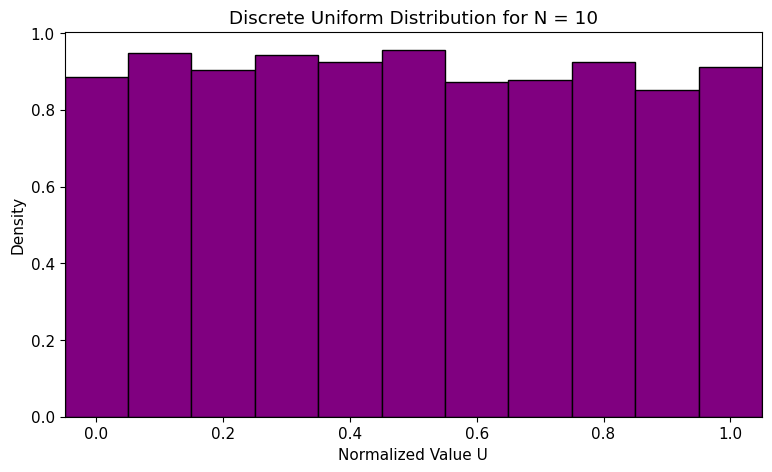

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    U_small,
    bins=np.arange(-0.05, 1.051, 0.1),
    density=True,
    edgecolor="black",
    color="purple"
)

plt.xlabel("Normalized Value U")
plt.ylabel("Density")
plt.title("Discrete Uniform Distribution for N = 10")
plt.xlim(-0.05, 1.05)

plt.show()

## 1.2 Continuous Limit for Large $N$

For

$$
N=2^{32}-1,
$$

the distance between consecutive normalized values is extremely small.

Consequently, the discrete gaps become visually negligible and the empirical
distribution approaches the continuous Uniform$(0,1)$ distribution.

The theoretical PDF is

$$
f(x)=1,\qquad 0\leq x\leq1.
$$

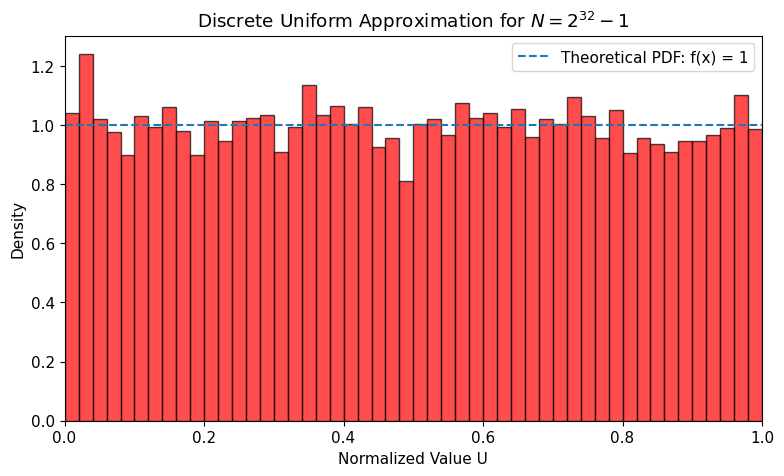

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    U_large,
    bins=50,
    density=True,
    edgecolor="black",
    alpha=0.7,
    color="red"
)

# Theoretical continuous PDF
plt.axhline(
    1,
    linestyle="--",
    label="Theoretical PDF: f(x) = 1"
)

plt.xlabel("Normalized Value U")
plt.ylabel("Density")
plt.title(r"Discrete Uniform Approximation for $N=2^{32}-1$")
plt.xlim(0, 1)
plt.legend()

plt.show()

## 1.3 Moment Verification

The theoretical variance of a continuous Uniform$(0,1)$ random variable is

$$
\operatorname{Var}(U)=\frac{1}{12}.
$$

The empirical variance is calculated separately for the small and large
values of $N$.

### Design Approach

Use NumPy's `np.var()` to calculate the empirical variance and compare the
result with the theoretical value.

### Complexity

For $m$ observations:

- **Time Complexity:** $O(m)$
- **Space Complexity:** $O(1)$ additional space apart from the input array.

In [ ]:
# Theoretical variance
theoretical_variance = 1 / 12

# Empirical variances
variance_small = np.var(U_small)
variance_large = np.var(U_large)

print(f"Theoretical variance : {theoretical_variance:.6f}")
print(f"Variance for N = 10  : {variance_small:.6f}")
print(f"Variance for large N : {variance_large:.6f}")

Theoretical variance : 0.083333
Variance for N = 10  : 0.099238
Variance for large N : 0.083566


## Observation

For $N=10$, the distribution exhibits visible discrete steps because only a
small number of normalized values are possible.

For the large value of $N$, the discrete gaps become extremely small and the
histogram visually approaches the continuous Uniform$(0,1)$ PDF.

The empirical variance for the large $N$ case should be close to the
theoretical value

$$
\frac{1}{12}\approx0.083333.
$$

Small differences are expected because the experiment uses a finite number
of random samples.

# 2. Generating Distributions via Inverse Transform

## Model Description

A standard Uniform$(0,1)$ random variable can be transformed into samples
from another probability distribution using the inverse of its cumulative
distribution function (CDF).

The generalized inverse CDF is defined as

$$
F^{-1}(u)
=
\inf\{x\in\mathbb{R}:F(x)\geq u\}.
$$

This allows a uniform probability space to be mapped to the target
distribution.

This section contains two parts:

- **Part A:** Continuous transformation using the Exponential distribution
- **Part B:** Discrete transformation using a step-function distribution

## 2.1 Part A — Continuous Transformation: Exponential Distribution

The CDF of an Exponential$(\lambda)$ random variable is

$$
F(x)=1-e^{-\lambda x}.
$$

Let

$$
U=F(X).
$$

Then

$$
U=1-e^{-\lambda X}.
$$

Solving for $X$:

$$
1-U=e^{-\lambda X}
$$

Taking the natural logarithm:

$$
\ln(1-U)=-\lambda X.
$$

Therefore,

$$
\boxed{
X=-\frac{\ln(1-U)}{\lambda}
}
$$

For this experiment,

$$
\lambda=2
$$

and 5,000 samples are generated.

### Design Approach

1. Generate 5,000 Uniform$(0,1)$ samples.
2. Apply the inverse exponential transformation.
3. Construct a normalized empirical histogram.
4. Overlay the theoretical exponential PDF.

### Complexity

For $m$ samples:

- **Time Complexity:** $O(m)$
- **Space Complexity:** $O(m)$

In [ ]:
NUM_EXP_SAMPLES = 5_000
LAMBDA = 2.0

# Generate Uniform(0,1) samples
U = rng.random(NUM_EXP_SAMPLES)

# Avoid log(0) and log(1)
U = np.clip(
    U,
    np.finfo(float).eps,
    1 - np.finfo(float).eps
)

# Inverse transform
X_exp = -np.log1p(-U) / LAMBDA

print("Number of samples:", len(X_exp))
print("Sample mean:", X_exp.mean())
print("Theoretical mean:", 1 / LAMBDA)

Number of samples: 5000
Sample mean: 0.4997036157907656
Theoretical mean: 0.5


## 2.2 Empirical Histogram and Theoretical PDF

For an Exponential$(\lambda)$ distribution, the theoretical PDF is

$$
f(x)=\lambda e^{-\lambda x}.
$$

For $\lambda=2$,

$$
f(x)=2e^{-2x}.
$$

The empirical histogram is normalized so that it represents a probability
density. The theoretical PDF is then plotted on the same axes for comparison.

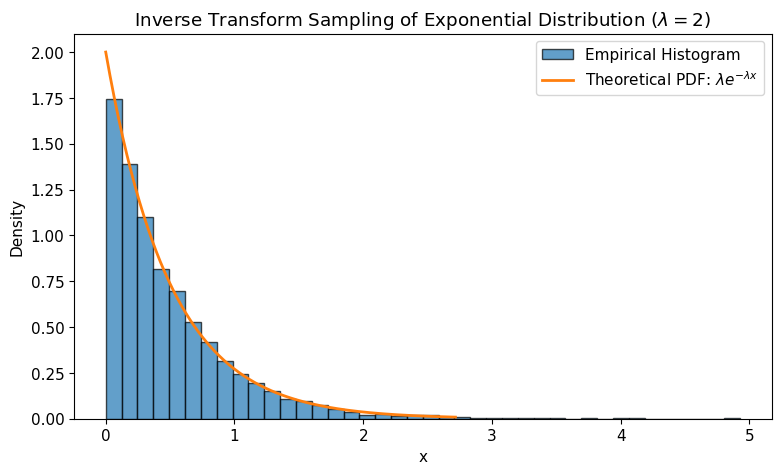

In [ ]:
# Generate x-values for theoretical PDF
x = np.linspace(
    0,
    np.percentile(X_exp, 99.5),
    500
)

# Theoretical PDF
theoretical_pdf = (
    LAMBDA * np.exp(-LAMBDA * x)
)

plt.figure(figsize=(9, 5))

plt.hist(
    X_exp,
    bins=40,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Empirical Histogram"
)

plt.plot(
    x,
    theoretical_pdf,
    linewidth=2,
    label=r"Theoretical PDF: $\lambda e^{-\lambda x}$"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title(
    r"Inverse Transform Sampling of Exponential Distribution ($\lambda=2$)"
)

plt.legend()
plt.show()

## Observation

The empirical histogram should closely follow the theoretical exponential
PDF.

The distribution has its highest density near $x=0$ and decreases
exponentially as $x$ increases.

The sample mean should also be close to the theoretical exponential mean:

$$
E[X]=\frac{1}{\lambda}.
$$

For $\lambda=2$:

$$
E[X]=\frac{1}{2}=0.5.
$$

## 2.3 Part B — Discrete Transformation

Consider a discrete distribution with

$$
p_1=0.2,\qquad
p_2=0.5,\qquad
p_3=0.3.
$$

The cumulative probabilities are

$$
F=[0.2,\;0.7,\;1.0].
$$

Therefore, the generalized inverse CDF maps Uniform$(0,1)$ samples as follows:

| Range of $U$ | Output |
|---|---:|
| $0 \leq U < 0.2$ | 1 |
| $0.2 \leq U < 0.7$ | 2 |
| $0.7 \leq U \leq 1$ | 3 |

### Design Approach

The cumulative probabilities are first calculated using `np.cumsum()`.

Then `np.searchsorted()` is used to efficiently determine the first
cumulative-probability boundary greater than or equal to each uniform sample.

### Complexity

For $m$ samples and $k$ categories:

- **Time Complexity:** $O(m\log k)$
- **Space Complexity:** $O(m)$

Since $k=3$, the computation is effectively linear in the number of samples.

In [ ]:
def inverse_discrete_sample(
    uniform_samples,
    values,
    probabilities
):
    """
    Generate samples from a discrete distribution
    using inverse-CDF sampling.
    """

    values = np.asarray(values)
    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    # Validate dimensions
    if values.ndim != 1 or probabilities.ndim != 1:
        raise ValueError(
            "Values and probabilities must be 1-dimensional."
        )

    # Validate lengths
    if len(values) != len(probabilities):
        raise ValueError(
            "Values and probabilities must have equal length."
        )

    # Validate probabilities
    if (
        np.any(probabilities < 0)
        or not np.isclose(probabilities.sum(), 1.0)
    ):
        raise ValueError(
            "Probabilities must be non-negative and sum to 1."
        )

    # Construct CDF
    cumulative_probabilities = np.cumsum(
        probabilities
    )

    # Find the corresponding bucket
    indices = np.searchsorted(
        cumulative_probabilities,
        uniform_samples,
        side="left"
    )

    return values[indices]

## 2.4 Generate Discrete Samples

A total of 5,000 Uniform$(0,1)$ values are generated and transformed into
samples from the specified discrete distribution.

The empirical frequencies are then compared with the theoretical
probabilities.

In [ ]:
NUM_DISCRETE_SAMPLES = 5_000

values = np.array([1, 2, 3])

probabilities = np.array([
    0.2,
    0.5,
    0.3
])

# Generate uniform samples
U_discrete = rng.random(
    NUM_DISCRETE_SAMPLES
)

# Apply inverse transform sampling
X_discrete = inverse_discrete_sample(
    U_discrete,
    values,
    probabilities
)

# Calculate frequencies
counts = np.bincount(
    X_discrete,
    minlength=4
)[1:]

frequencies = (
    counts / NUM_DISCRETE_SAMPLES
)

print("Value:", values)
print("Theoretical probabilities:", probabilities)
print("Empirical frequencies:", np.round(frequencies, 4))

Value: [1 2 3]
Theoretical probabilities: [0.2 0.5 0.3]
Empirical frequencies: [0.1986 0.4918 0.3096]


## 2.5 Resulting Frequencies

The empirical frequencies should be approximately equal to the specified
probabilities:

$$
P(X=1)=0.2,
$$

$$
P(X=2)=0.5,
$$

and

$$
P(X=3)=0.3.
$$

The small differences between empirical and theoretical values are caused by
finite-sample randomness.

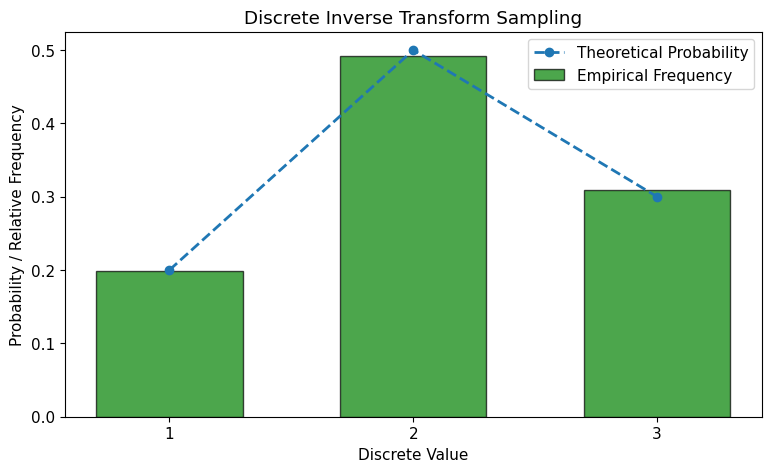

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    values,
    frequencies,
    width=0.6,
    edgecolor="black",
    color="green",
    alpha=0.7,
    label="Empirical Frequency"
)

plt.plot(
    values,
    probabilities,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Theoretical Probability"
)

plt.xlabel("Discrete Value")
plt.ylabel("Probability / Relative Frequency")
plt.title("Discrete Inverse Transform Sampling")
plt.xticks(values)

plt.legend()
plt.show()

# 3. Binomial Convergence & the Infinite Limit

## Model Description

The Binomial distribution represents the number of successes in $n$
independent Bernoulli trials.

Let

$$
Y\sim\operatorname{Binomial}(n,p).
$$

Equivalently,

$$
Y=\sum_{i=1}^{n}B_i,
$$

where each

$$
B_i\sim\operatorname{Bernoulli}(p).
$$

The sample proportion of successes is

$$
\hat{p}=\frac{Y}{n}.
$$

Its theoretical variance is

$$
\operatorname{Var}(\hat{p})
=
\frac{p(1-p)}{n}.
$$

Therefore,

$$
\lim_{n\rightarrow\infty}
\operatorname{Var}(\hat{p})
=
0.
$$

This experiment verifies this convergence computationally.

### Design Approach

1. Generate a Binomial variable as the sum of Bernoulli trials.
2. Generate sample proportions for increasing values of $n$.
3. Use logarithmically increasing values from $10$ to $100,000$.
4. Calculate empirical variance for every value of $n$.
5. Compare the empirical variance with the theoretical curve
   $p(1-p)/n$.

### Complexity

For $m$ observations and $n$ explicit Bernoulli trials:

- **Time Complexity:** $O(mn)$
- **Space Complexity:** $O(mn)$ if all trials are stored.

For the large experiment, NumPy's optimized Binomial generator is used to
avoid constructing a large Bernoulli matrix.

## 3.1 Simulation Using Bernoulli Trials

A Binomial random variable can be constructed by summing independent
Bernoulli random variables.

For demonstration, a small value of $n$ is used to explicitly generate the
Bernoulli trials and calculate their sum.

In [ ]:
p = 0.4
n_demo = 20
NUM_DEMO_SAMPLES = 5_000

# Generate independent Bernoulli trials
bernoulli_trials = (
    rng.random(
        (NUM_DEMO_SAMPLES, n_demo)
    ) < p
)

# Sum the Bernoulli trials
Y_demo = bernoulli_trials.sum(axis=1)

# Calculate sample proportion
p_hat_demo = Y_demo / n_demo

print(
    "Empirical mean of p_hat:",
    p_hat_demo.mean()
)

print(
    "True probability p:",
    p
)

Empirical mean of p_hat: 0.39788
True probability p: 0.4


## 3.2 Rolling Variance

The experiment now uses logarithmically increasing values of $n$ from

$$
10\leq n\leq100,000.
$$

The true probability is held constant at

$$
p=0.4.
$$

For each value of $n$:

1. Generate Binomial observations.
2. Calculate the sample proportion $\hat p$.
3. Calculate its empirical variance.
4. Calculate the theoretical variance

$$
\frac{p(1-p)}{n}.
$$

In [ ]:
# Logarithmically increasing values of n
n_values = np.unique(
    np.logspace(
        np.log10(10),
        np.log10(100_000),
        20
    ).astype(int)
)

NUM_BINOMIAL_SAMPLES = 10_000

empirical_variances = []
theoretical_variances = []

for n in n_values:

    # Generate Binomial observations
    Y = rng.binomial(
        n=n,
        p=p,
        size=NUM_BINOMIAL_SAMPLES
    )

    # Calculate sample proportions
    p_hat = Y / n

    # Empirical variance
    empirical_variances.append(
        np.var(p_hat, ddof=1)
    )

    # Theoretical variance
    theoretical_variances.append(
        p * (1 - p) / n
    )

empirical_variances = np.asarray(
    empirical_variances
)

theoretical_variances = np.asarray(
    theoretical_variances
)

print("Values of n:")
print(n_values)

Values of n:
[    10     16     26     42     69    112    183    297    483    784
   1274   2069   3359   5455   8858  14384  23357  37926  61584 100000]


## 3.3 Visualization of Variance Convergence

The empirical variance is plotted against $n$ using logarithmic scales on
both axes.

The theoretical relationship is

$$
\operatorname{Var}(\hat p)
=
\frac{p(1-p)}{n}.
$$

As $n$ increases, the theoretical variance decreases toward zero.

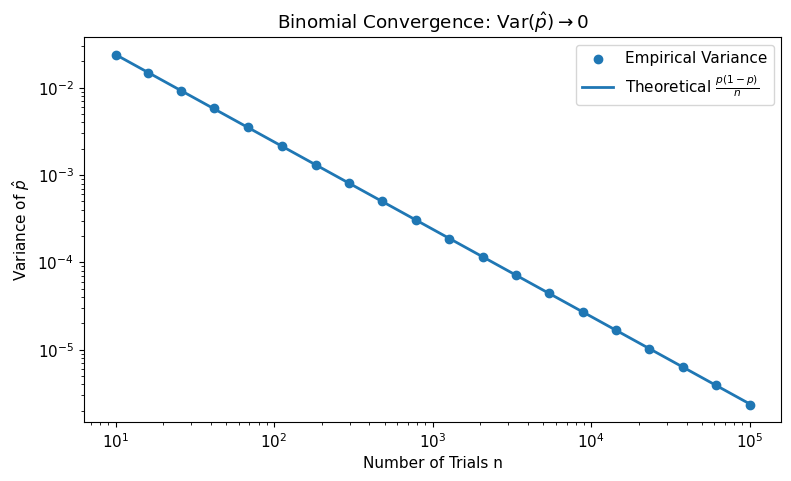

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(
    n_values,
    empirical_variances,
    label="Empirical Variance"
)

plt.plot(
    n_values,
    theoretical_variances,
    linewidth=2,
    label=r"Theoretical $\frac{p(1-p)}{n}$"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of Trials n")
plt.ylabel(r"Variance of $\hat{p}$")

plt.title(
    r"Binomial Convergence: "
    r"$\operatorname{Var}(\hat{p}) \rightarrow 0$"
)

plt.legend()
plt.show()

## Observation

The empirical variance decreases as the number of trials $n$ increases.

The experimental results follow the theoretical relationship

$$
\operatorname{Var}(\hat p)
=
\frac{p(1-p)}{n}.
$$

Since the numerator remains constant while $n$ increases,

$$
\frac{p(1-p)}{n}\rightarrow0.
$$

Hence,

$$
\boxed{
\lim_{n\rightarrow\infty}
\operatorname{Var}(\hat p)=0
}
$$

This demonstrates computationally that the sample proportion becomes
increasingly concentrated around the true probability $p$ as the number of
trials increases.

# 4. Discrete Convolution in Practice

## Model Description

When $X$ and $Y$ are independent discrete random variables, the PMF of their
sum

$$
Z=X+Y
$$

is obtained using discrete convolution:

$$
p_Z(z)
=
\sum_x p_X(x)p_Y(z-x).
$$

In this experiment, $X$ and $Y$ represent two independent fair six-sided
dice.

For each die,

$$
P(X=x)=\frac{1}{6},
\qquad
x\in\{1,2,3,4,5,6\}.
$$

The objective is to compare:

1. The empirical distribution obtained through simulation.
2. The exact mathematical PMF obtained using `np.convolve()`.

### Design Approach

1. Generate 100,000 independent rolls for each die.
2. Calculate the sum of the two dice.
3. Calculate the empirical PMF.
4. Construct the theoretical PMF of one die.
5. Convolve the two PMFs using `np.convolve()`.
6. Plot the empirical distribution and exact convolution together.

### Complexity

For $m$ simulated rolls:

- **Simulation Time Complexity:** $O(m)$
- **Simulation Space Complexity:** $O(m)$

For two PMFs of length $k$:

- **Convolution Time Complexity:** $O(k^2)$
- **Convolution Space Complexity:** $O(k)$

Here $k=6$, so the convolution is computationally inexpensive.

## 4.1 Simulating Two Fair Dice

Each die is independently generated using a discrete uniform distribution over

$$
\{1,2,3,4,5,6\}.
$$

The sum is calculated as

$$
Z=X+Y.
$$

Therefore, the possible values of $Z$ are

$$
\{2,3,4,\ldots,12\}.
$$

In [ ]:
NUM_DICE_TRIALS = 100_000

# Generate rolls for two independent dice
X = rng.integers(
    1,
    7,
    size=NUM_DICE_TRIALS
)

Y = rng.integers(
    1,
    7,
    size=NUM_DICE_TRIALS
)

# Calculate sums
Z = X + Y

sum_values = np.arange(2, 13)

print(
    "Number of simulated trials:",
    NUM_DICE_TRIALS
)

print(
    "Possible sums:",
    sum_values
)

Number of simulated trials: 100000
Possible sums: [ 2  3  4  5  6  7  8  9 10 11 12]


## 4.2 Theoretical PMF Using Convolution

The PMF of a single fair die is

$$
p_X=
\left[
\frac16,\frac16,\frac16,
\frac16,\frac16,\frac16
\right].
$$

Since the two dice are independent, the PMF of their sum can be calculated
using discrete convolution:

$$
p_Z=p_X*p_Y.
$$

NumPy's `np.convolve()` is used to perform this calculation.

In [ ]:
# PMF of one fair die
die_pmf = np.full(
    6,
    1 / 6
)

# Exact PMF of the sum
exact_pmf = np.convolve(
    die_pmf,
    die_pmf
)

# Empirical PMF
empirical_counts = np.bincount(
    Z,
    minlength=13
)[2:13]

empirical_pmf = (
    empirical_counts /
    NUM_DICE_TRIALS
)

print("Sum values:")
print(sum_values)

print("\nEmpirical PMF:")
print(np.round(empirical_pmf, 4))

print("\nExact convolution PMF:")
print(np.round(exact_pmf, 4))

Sum values:
[ 2  3  4  5  6  7  8  9 10 11 12]

Empirical PMF:
[0.0288 0.0564 0.0833 0.1111 0.1392 0.1644 0.1391 0.111  0.0844 0.0551
 0.0273]

Exact convolution PMF:
[0.0278 0.0556 0.0833 0.1111 0.1389 0.1667 0.1389 0.1111 0.0833 0.0556
 0.0278]


## 4.3 Empirical Distribution vs Exact Convolution

The empirical distribution is represented using a bar chart.

The exact mathematical distribution obtained from convolution is represented
using a stem plot.

If the simulation is sufficiently large, the empirical bars should closely
match the exact convolution values.

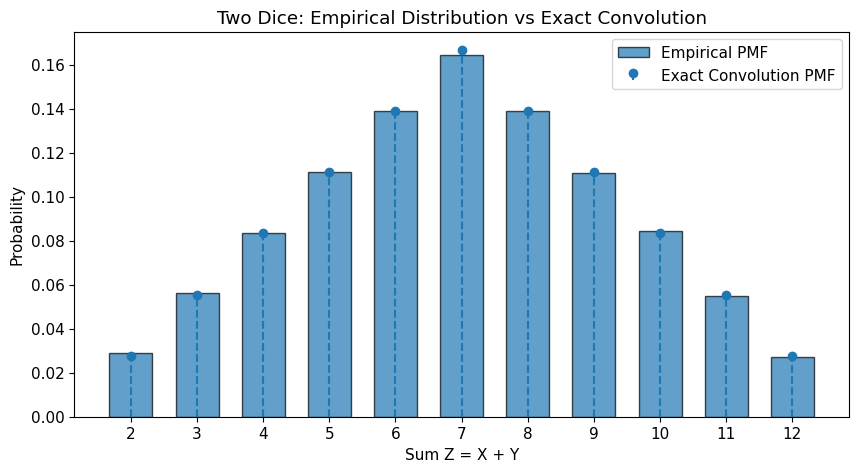

In [ ]:
plt.figure(figsize=(10, 5))

# Empirical PMF
plt.bar(
    sum_values,
    empirical_pmf,
    width=0.65,
    alpha=0.7,
    edgecolor="black",
    label="Empirical PMF"
)

# Exact convolution PMF
plt.stem(
    sum_values,
    exact_pmf,
    linefmt="--",
    markerfmt="o",
    basefmt=" ",
    label="Exact Convolution PMF"
)

plt.xlabel("Sum Z = X + Y")
plt.ylabel("Probability")
plt.title(
    "Two Dice: Empirical Distribution vs Exact Convolution"
)

plt.xticks(sum_values)
plt.legend()

plt.show()

## Observation

The possible sums range from 2 to 12.

The sum $7$ has the highest probability because it can be obtained in six
different ways:

$$
(1,6),(2,5),(3,4),(4,3),(5,2),(6,1).
$$

The extreme sums $2$ and $12$ each have only one possible combination:

$$
2=(1,1)
$$

and

$$
12=(6,6).
$$

Therefore, the theoretical PMF has a symmetric triangular shape.

The empirical distribution generated from 100,000 trials should closely match
the exact PMF calculated using `np.convolve()`. Small differences occur due
to random sampling variability.

# Final Conclusion

The experiments performed in this lab demonstrate four important statistical
concepts.

### 1. Discrete and Continuous Uniforms

A normalized discrete uniform random variable approaches a continuous
Uniform$(0,1)$ distribution as the state space $N$ becomes increasingly large.

### 2. Inverse Transform Sampling

A Uniform$(0,1)$ random variable can be transformed into samples from both
continuous and discrete distributions using the inverse CDF.

For the exponential distribution:

$$
X=-\frac{\ln(1-U)}{\lambda}.
$$

For the discrete distribution, cumulative probabilities are used to assign
each uniform value to its corresponding probability bucket.

### 3. Binomial Convergence

The variance of the sample proportion is

$$
\operatorname{Var}(\hat p)
=
\frac{p(1-p)}{n}.
$$

As $n$ approaches infinity,

$$
\operatorname{Var}(\hat p)\rightarrow0.
$$

### 4. Discrete Convolution

The PMF of the sum of independent discrete random variables can be obtained
using convolution. The empirical distribution obtained through simulation
closely agrees with the exact PMF calculated using `np.convolve()`.

Overall, the simulations provide computational verification of the theoretical
statistical results specified in the lab.